[활동목표]

머신러닝으로 해결할 수 있는 문제를 선정하고 머신러닝 과정을 통해 예측해 보자.

[활동개요]

공공 자전거는 주민들의 편의와 교통 체증, 대기 오염 문제를 해결하기 위해 자치 기관에서 운영하는 공공 서비스로 사람들의 수요에 맞게 자전거를 배치하는 것이 관건이다. 서울시 공공 자전거 대여 건수를 예측하기 위해 필요한 데이터 속성을 찾아보고, 여러 공공 데이터를 수집해서 전처리와 탐색적 데이터 분석 과정을 거쳐
학습할 수 있는 데이터를 준비한다. 평균 기온, 강수량, 요일에 따른 공공 자전거 대여 건수 데이터 세트를 훈련용과 평가용 데이터로 나눠서 선형 회귀 모델로 학습시키고 평가한 후 새로운 평균기온, 강수량, 요일을 입력했을 때 공공 자전거 대여 건수를 예측하는 프로그램을 만들어 보자.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   # 시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 # 해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

머신러닝 과정으로 서울시의 공공 자전거 수요를 예측해 보자.

####1. 문제 정의

공공 자전거는 공공재이므로 언제나 누구든지 사용할 수 있
도록 자전거를 적재적소에 배치하는 것이 중요하다. 따라서 공
공 자전거 대여에 필요한 속성을 찾아보고 필요한 데이터를 수
집해야 한다. 우선 공공 자전거 대여에 미치는 요소는 워낙 다
양하므로 본 활동에서는 기온, 요일, 강수량을 속성으로 서울시
전체의 공공 자전거 대여 건수를 예측하는 모델을 만들어 보자

####2. 데이터 수집

수집할 데이터는 기온, 요일, 강수량, 서울시 공공 자전거 대여 건수이며, 이는 모두 공공 데이터로 공개되고 있다.

① 서울시 공공 자전거 대여 데이터 찾아보기

*   서울 열린 데이터 광장 사이트에서 서울시 공공 자전거 이용 현황의 일별 대여 건수 데이터를 다운로드하자.
*   도움 자료 http://data.seoul.go.kr/dataList/OA-14994/F/1/datasetView.do#
*   2020년부터는 코로나19로 인한 대여수 급감으로 일반적인 대여현황이라고 보기 어렵기 때문에 2018년 1월부터 2019년 3월까지의 데이터를 다운로드한 후에 파
일명을 ‘seoul_rent_bike.csv’로 변경한다.
*   해당 날짜에 필요한 평균기온과 강수량, 요일 데이터를 찾아 속성을 추가해 보자.

② 기온 데이터 세트 수집하기

* 기상청 기상 자료 개방 포털의 [기후통계분석]-[통계분석]-[기온분석] 검색창에서 자료 구분은 [일], 기간은[20180101~20190331], 지역은 [서울]로 설정하여 검색한 후 csv 파일을 다운로드해 보자.
* 도움 자료 https://data.kma.go.kr
* 해당 날짜에 맞는 ‘평균기온’을 복사하여 공공 자전거 대여 건수 데이터 세트(seoul_rent_bike.csv)에 추가한다.

③ 강수량 데이터 세트 수집하기

* 기상청 기상 자료 개방 포털의 [기후통계분석]-[통계분석]-[강수량분석] 검색창에서 자료 구분은 [일], 기간은 [20180101~20190331], 지역은 [서울]로 선택하여 csv 파일을 다운로드해 보자.
* 도움 자료 https://data.kma.go.kr
* 해당 날짜에 맞는 강수량을 복사하여 공공 자전거 대여 건수 데이터 세트(seoul_rent_bike.csv)에 추가한다.


④ 요일 데이터 추가하기

요일은 월~일까지 계속 반복되기 때문에 스프레드시트 프로그램의 자동 채우기 기능을 이용하면 쉽게 데이터를 채울 수 있다. 데이터 세트의 시작 지점인 2018-01-01은 월요일이므로 자동으로 데이터를 추가하여 다음과 같이
데이터 세트를 완성해 보자.

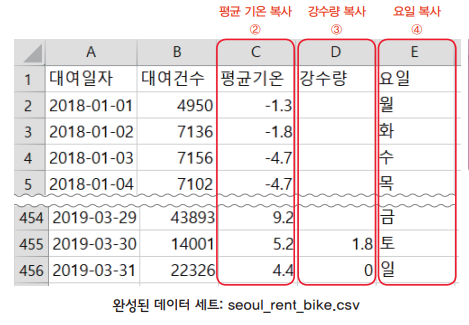

⑤ 라이브러리 불러오기

In [2]:
# pandas, numpy 및 pyplot 라이브러리를 불러온다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 로컬 컴퓨터의 파일을 코랩으로 업로드한다.
from google.colab import files
files.upload()

Saving seoul_rent_bike.csv to seoul_rent_bike (2).csv


{'seoul_rent_bike (2).csv': b'\xb4\xeb\xbf\xa9\xc0\xcf\xc0\xda,\xb4\xeb\xbf\xa9\xb0\xc7\xbc\xf6,\xc6\xf2\xb1\xd5\xb1\xe2\xbf\xc2,\xb0\xad\xbc\xf6\xb7\xae,\xbf\xe4\xc0\xcf\r\n2018-01-01,4950,-1.3,,\xbf\xf9\r\n2018-01-02,7136,-1.8,,\xc8\xad\r\n2018-01-03,7156,-4.7,,\xbc\xf6\r\n2018-01-04,7102,-4.7,,\xb8\xf1\r\n2018-01-05,7705,-3,,\xb1\xdd\r\n2018-01-06,5681,-2.8,,\xc5\xe4\r\n2018-01-07,5220,-0.8,,\xc0\xcf\r\n2018-01-08,6309,1.3,0.9,\xbf\xf9\r\n2018-01-09,5988,-4.2,0.5,\xc8\xad\r\n2018-01-10,4476,-7.5,0.3,\xbc\xf6\r\n2018-01-11,4337,-11.1,,\xb8\xf1\r\n2018-01-12,4401,-10.2,0,\xb1\xdd\r\n2018-01-13,3756,-4.4,0.4,\xc5\xe4\r\n2018-01-14,4675,0.6,,\xc0\xcf\r\n2018-01-15,6993,4.7,0.2,\xbf\xf9\r\n2018-01-16,7421,3.5,0,\xc8\xad\r\n2018-01-17,6990,4.5,,\xbc\xf6\r\n2018-01-18,7054,2.1,0,\xb8\xf1\r\n2018-01-19,8329,1,,\xb1\xdd\r\n2018-01-20,6148,2.2,,\xc5\xe4\r\n2018-01-21,5574,0.4,,\xc0\xcf\r\n2018-01-22,4929,0.2,3.3,\xbf\xf9\r\n2018-01-23,4263,-11.7,,\xc8\xad\r\n2018-01-24,3370,-14.2,,\xbc\xf6\r\

In [3]:
# 업로드한 'seoul_rent_bike.csv' 파일을 df_bike에 저장한다(한글 인코딩으로 설정).
df_bike = pd.read_csv('seoul_rent_bike.csv',encoding='cp949')

# df_bike의 5개 데이터를 출력한다
df_bike.head()

,대여일자,대여건수,평균기온,강수량,요일
0,2018-01-01,4950,-1.3,NaN,월
1,2018-01-02,7136,-1.8,NaN,화
2,2018-01-03,7156,-4.7,NaN,수
3,2018-01-04,7102,-4.7,NaN,목
4,2018-01-05,7705,-3.0,NaN,금


5개의 데이터만 보았을 때도 강수량 데이터는 결측치가 많을 것으로 예상되므로 데이터를 전체적으로 분석하는 단계가 필요하다.

####3. 탐색적 데이터 분석

데이터의 전반적인 형태를 살펴보기 위해 탐색적 데이터 분석을 해 보자.

① 데이터 세트의 통계 정보 확인하기

데이터 속성의 통계 대푯값을 확인하고, 데이터 타입, 결측치 등을 확인해 보자.

In [4]:
# 저장된 데이터의 빈칸이 아닌 값과 자료형을 확인한다
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   대여일자    455 non-null    object 
 1   대여건수    455 non-null    int64  
 2   평균기온    455 non-null    float64
 3   강수량     152 non-null    float64
 4   요일      455 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 17.9+ KB


총 5개의 속성이 있으며 ‘대여 건수’는 정수형, ‘평균기온’과
‘강수량’은 실수형, ‘대여일자’와 ‘요일’은 문자형 데이터로 불러
온 것을 확인할 수 있다. 강수량 데이터는 455개 중 302건이
없고 152개만 있으므로 전처리가 필요하다.

In [5]:
# 데이터의 개수, 평균, 표준편차 등의 대푯값을 분석한다.
df_bike.describe()

,대여건수,평균기온,강수량
count,455.000000,455.000000,152.000000
mean,26366.613187,10.913407,8.780921
std,15476.046814,11.302373,17.472805
min,1037.000000,-14.800000,0.000000
25%,13145.500000,1.900000,0.100000
50%,25537.000000,9.700000,1.000000
75%,39022.500000,21.100000,7.500000
max,64671.000000,33.700000,96.500000


총 455건의 데이터가 있으며 describe( ) 함수에서 수치형 데이터의 통계치가 표시되므로 ‘대여일자’와 ‘요일’을 제외한 ‘대여건수’, ‘평균기온’,
‘강수량’에 대한 통계치를 확인할 수 있다. 이때 ‘평균기온’은 –14도에서 33.7도까지 분포하고 있으며 ‘강수량’은 0~96.5mm까지 저장되어 있다. ‘대여건수’는 1037 ~ 64671건으로 차이가 상당히 큰 것을 확인할 수 있다.

② 결측치 데이터 처리하기

결측치가 나타난 강수량 데이터를 처리해 보자.

* 강수량 데이터는 455건 중 302건이 없으므로 이 데이터를 제거하면 너무 많은 데이터가 사라지게 된다. 따라
서 이전값, 다음값, 평균값, 특정값 채우기 중에 하나를 선택하여 결측치를 처리해야 한다.
* ‘강수량’은 비가 오는 날이 많지 않기 때문에 빈 데이터를 0으로 채우는 것이 합리적으로 보인다.

In [6]:
#결측 데이터를 0으로 채우기
df_bike=df_bike.fillna(0)
df_bike.head()

,대여일자,대여건수,평균기온,강수량,요일
0,2018-01-01,4950,-1.3,0.0,월
1,2018-01-02,7136,-1.8,0.0,화
2,2018-01-03,7156,-4.7,0.0,수
3,2018-01-04,7102,-4.7,0.0,목
4,2018-01-05,7705,-3.0,0.0,금


강수량 데이터의 결측치가 0.0(실수값)으로 채워진 것을 확인할 수 있다.

③ 탐색적 데이터 분석‌

*   데이터 세트의 속성인 ‘평균기온’, ‘강수량’, ‘요일’에 따른 ‘대여 건수’를
시각화해서 데이터의 특성을 대략적으로
파악해 보자. 이때 데이터에 포함된 한글을 시각화 그래프에 표현하기 위해 코랩의 한글 폰트를 설치해야 한다.

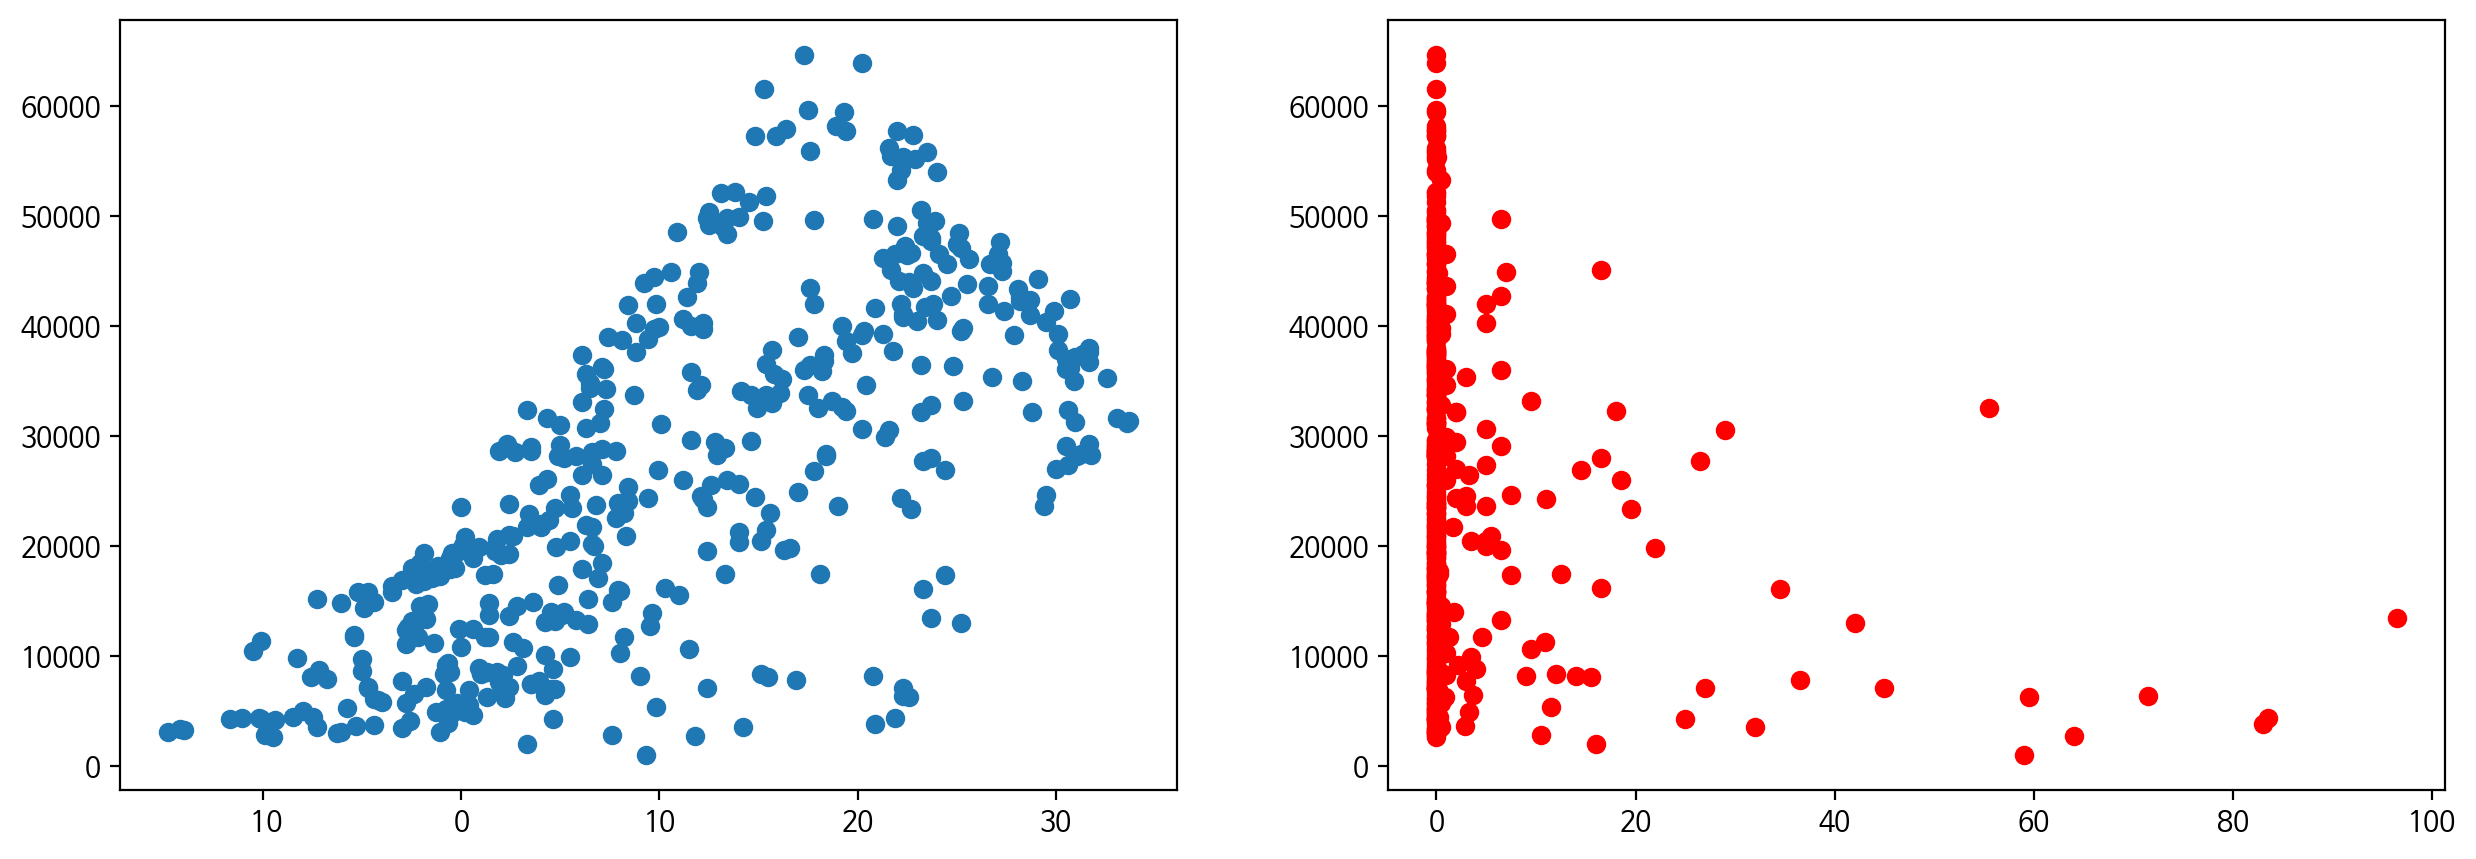

In [8]:
# 2개의 그래프를 설정하고, 그래프의 크기는 15×5인치로 설정한다.
plt.figure(2, figsize = (15, 5))

# 첫 번째 그래프에는 ‘평균기온’에 따른 ‘대여건수’를 표시한다.
plt.subplot(1,2,1)
plt.scatter(df_bike['평균기온'],df_bike['대여건수'])

#두 번째 그래프에는 ‘강수량’에 따른 ‘대여건수’를 표시한다.
plt.subplot(1,2,2)
plt.scatter(df_bike['강수량'],df_bike['대여건수'],c='r')

plt.show( )


*   첫 번째 그래프 : ‘평균기온’에 따른 대여 건수는 영하에
서 18도 정도까지는 상승하는 형태이며,
20도가 넘어가면서 대여 건수가 줄어드
는 것을 확인할 수 있다.

*   두 번째 그래프 :  강수량에 따른 자전거 대여 건수는 데이터 대부분이
0mm인 것을 감안해야 한다. 강수량이 30mm를 넘어
갈 때는 특이한 경우를 제외하고 대여 건수가 낮은 것
을 확인할 수 있다.

<ipython-input-16-b1098e80e703>:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_bike.groupby('요일').mean()['대여건수'].plot(figsize=(7,5),kind='bar',rot=0)


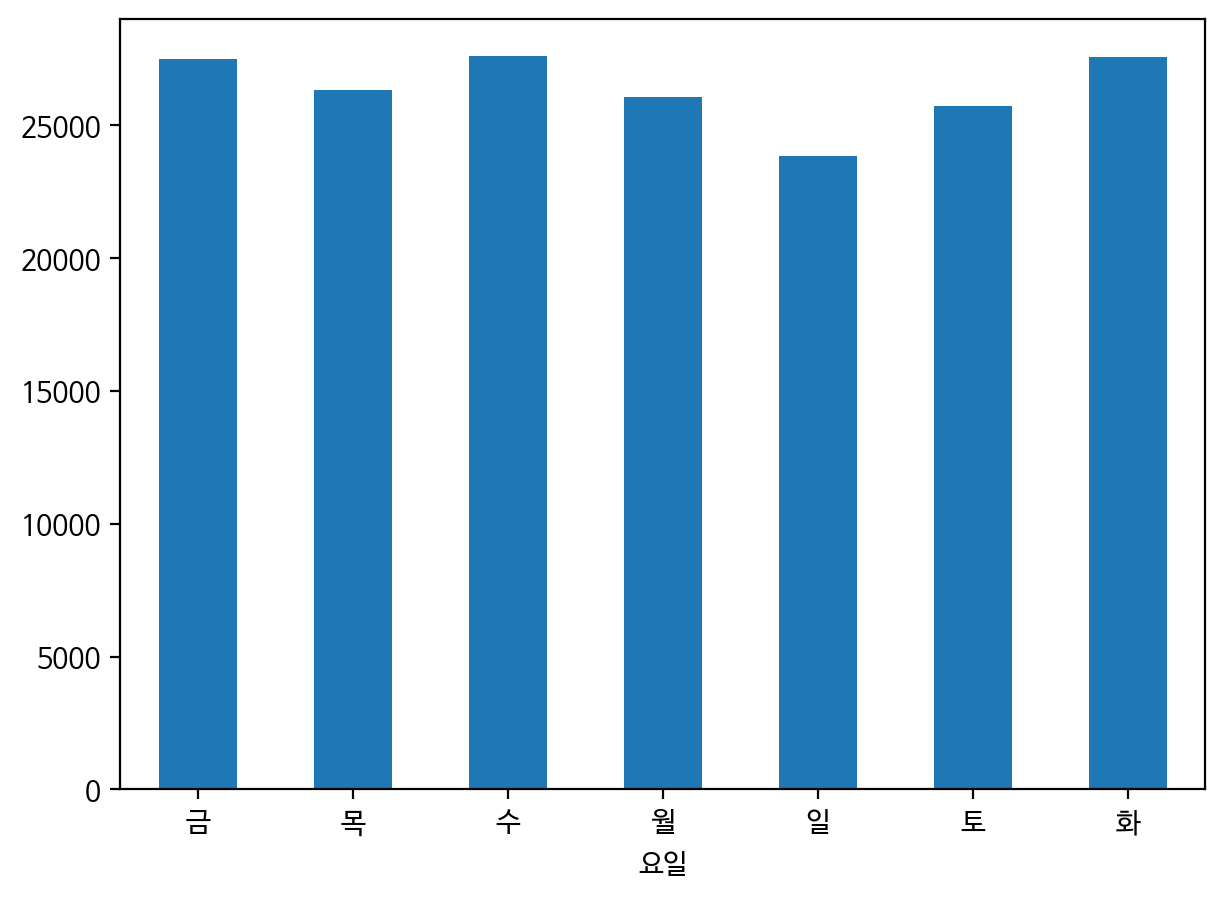

In [16]:
# pandas 라이브러리의 plot( ) 메서드를 이용해서
# 요일에 따른 ‘대여건수’ 평균을 막대그래프로 표시한다.
df_bike.groupby('요일').mean()['대여건수'].plot(figsize=(7,5),kind='bar',rot=0)
plt.show()



*   위와 동일한 데이터를 원그래프로 표현해 보자.

 autopct: pie차트에서 비율을 표시하는 옵션으로 %.2f는 소수
점 셋째 자리에서 반올림해서 소수점 둘째 자리까지 보여 준다.



<ipython-input-20-5e52fb2a32aa>:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_bike.groupby('요일').mean()['대여건수'].plot(kind='pie',autopct='%.2f%%')


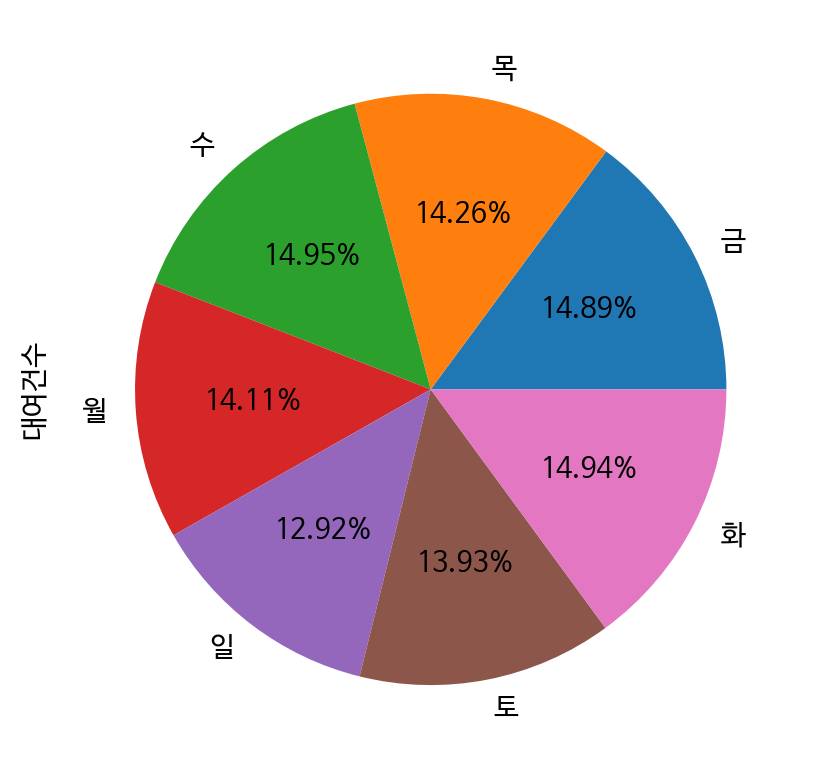

In [20]:
# pandas 라이브러리의 plot( ) 메서드를 이용해서
# 요일에 따른 대여 건수 평균을 원그래프로 표시한다.

df_bike.groupby('요일').mean()['대여건수'].plot(kind='pie',autopct='%.2f%%')
plt.show()

공공 자전거는 주말에 대여 건수가 많을 거라 예상했으나 요일별로 큰 차이가 없으며, 오히려 토요일과 일요일의 대여 건수가 적다는 점을 확인할 수 있다.

####4. 탐색적 전처리

수집한 데이터를 학습에 적합한 데이터의 형태로 전처리해 보자.

① 요일 속성 원-핫 인코딩(One Hot Encoding)
* 문자를 숫자, 더 구체적으로는 벡터로 바꾸는 원-핫 인코딩
* 요일 속성을 원-핫 인코딩으로 변환해 보자.
* 요일 속성은 범주형 데이터이기 때문에 카테고리만큼의 속성을 만들고 해당 속성에만 ‘1’을 저장하고 나머지에는 ‘0’을 저장, 원-핫 인코딩으로 변환해야 학습과 예측을 할 수 있다.
* 원-핫 인코딩하는 이유 :
수많은 0과 하나의 1로 데이터를 구별하는 방법으로 벡터에 하나만 1의 값을 가짐으로써 데이터를 구분 짓도록 하는 것이다. 데이터가
가지는 값의 크기가 중요하지 않은 범주형일 때 원-핫 인코딩을 통해 데이터의 분류를 할 수 있다.

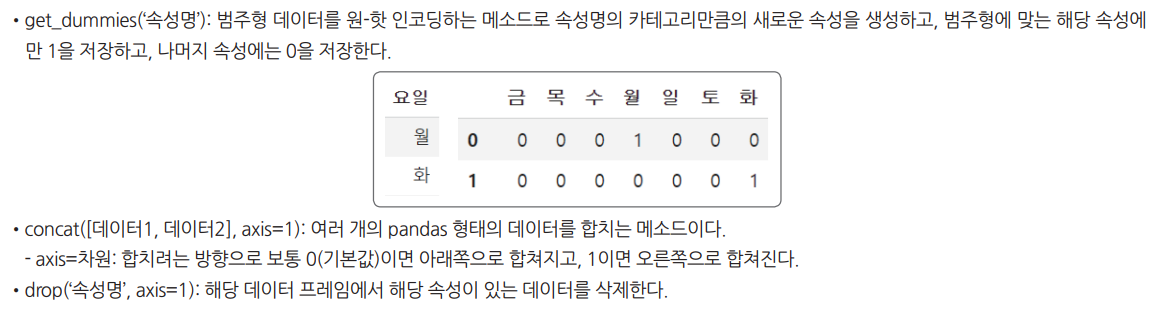

In [21]:
# ‘요일’ 속성만 원-핫 인코딩 방식으로 변환한다.
one_hot_week = pd.get_dummies(df_bike['요일'])

# 원-핫 인코딩 데이터와 df_bike를 합쳐 df_bike2에 저장한다.
df_bike2 = pd.concat([one_hot_week, df_bike],axis=1)

# df_bike2에서 ‘요일’ 속성을 제거한다.
df_bike2.drop(['요일'], axis = 1, inplace =True)

# df_bike2에서 ‘대여일자’ 속성을 제거한다.
df_bike2.drop(['대여일자'], axis = 1, inplace = True)

df_bike2.head()

,금,목,수,월,일,토,화,대여건수,평균기온,강수량
0,0,0,0,1,0,0,0,4950,-1.3,0.0
1,0,0,0,0,0,0,1,7136,-1.8,0.0
2,0,0,1,0,0,0,0,7156,-4.7,0.0
3,0,1,0,0,0,0,0,7102,-4.7,0.0
4,1,0,0,0,0,0,0,7705,-3.0,0.0


In [22]:
one_hot_week

,금,목,수,월,일,토,화
0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0
3,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...
450,0,0,1,0,0,0,0
451,0,1,0,0,0,0,0
452,1,0,0,0,0,0,0
453,0,0,0,0,0,1,0


In [23]:
df_bike

,대여일자,대여건수,평균기온,강수량,요일
0,2018-01-01,4950,-1.3,0.0,월
1,2018-01-02,7136,-1.8,0.0,화
2,2018-01-03,7156,-4.7,0.0,수
3,2018-01-04,7102,-4.7,0.0,목
4,2018-01-05,7705,-3.0,0.0,금
...,...,...,...,...,...
450,2019-03-27,35832,11.6,0.0,수
451,2019-03-28,38806,9.4,0.0,목
452,2019-03-29,43893,9.2,0.0,금
453,2019-03-30,14001,5.2,1.8,토


② 데이터 전처리

데이터 세트 중 데이터(X)와 레이블(y)로 분리해 보자.

In [26]:
#df_bike2에서 ‘대여건수’ 속성을 제외한 속성을 훈련용 데이터로 저장한다.
X =df_bike2.drop(['대여건수'],axis=1)

#df_bike2에서 ‘대여건수’ 속성만 추출해서 레이블로 저장한다.
y =df_bike2['대여건수']

#데이터와 레이블의 형태를 출력한다.
print(X.shape, y.shape)

(455, 9) (455,)


In [28]:
X

,금,목,수,월,일,토,화,평균기온,강수량
0,0,0,0,1,0,0,0,-1.3,0.0
1,0,0,0,0,0,0,1,-1.8,0.0
2,0,0,1,0,0,0,0,-4.7,0.0
3,0,1,0,0,0,0,0,-4.7,0.0
4,1,0,0,0,0,0,0,-3.0,0.0
...,...,...,...,...,...,...,...,...,...
450,0,0,1,0,0,0,0,11.6,0.0
451,0,1,0,0,0,0,0,9.4,0.0
452,1,0,0,0,0,0,0,9.2,0.0
453,0,0,0,0,0,1,0,5.2,1.8


In [29]:
y

0       4950
1       7136
2       7156
3       7102
4       7705
       ...  
450    35832
451    38806
452    43893
453    14001
454    22326
Name: 대여건수, Length: 455, dtype: int64

데이터는 455개로 9개의 속성을 가지고 있으며 레이블은 455개로 1개의 속성이 있다

③ 훈련용 및 평가용 데이터로 나누기

사이킷런의 train_test_split( ) 함수를 이용하여 훈련용 데이터, 평가용 데이터, 훈련용 레이블, 평가용 레이블로 나눠 보자.

In [37]:
# 데이터를 나누기 위해 train_test_split 함수를 불러온다.
from sklearn.model_selection import train_test_split

# 훈련용 데이터(X_train), 평가용 데이터(X_test),
# 훈련용 레이블(y_train), 평가용 레이블(y_test)에 데이터(X)와 레이블(y)을 나눈다.
# 이때, 데이터를 섞은 후에 나뉘게 되며, 훈련용과 평가용을 80:20의 비율로 나눈다.
X_train,X_test,y_train,y_test = train_test_split(X,y,shuffle=True,test_size=0.2)

# 훈련용 및 평가용 데이터와 레이블의 형태를 출력한다.
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(364, 9) (91, 9) (364,) (91,)


훈련용과 평가용이 364개, 91개로 각각 나뉘어졌음을 확인할 수 있다.

####5. 모델 학습 및 평가

전처리된 데이터를 이용해 인공지능 모델을 학습시키고 모델을 평가해 보자.

① 선형 회귀 모델 불러오고 학습하기

사이킷런에서 제공하는 선형 회귀 함수를 불러와 훈련용 데이터(X_train)와 훈련용 레이블(y_train)을 fit( ) 함수로 학습시켜 보자.

In [35]:
# sklearn의 LinearRegression 함수를 불러온다.
from sklearn.linear_model import LinearRegression

# 훈련용 데이터와 레이블을 fit( ) 함수로 학습시키고, 그 결과를 model에 저장한다.
model=LinearRegression().fit(X_train,y_train)

② 모델 평가하기

학습이 잘 되었는지 그리고 모델을 얼마나 신뢰할 수 있는지를 확인하기 위해 모델을 평가해 보자.

*   회귀에서는 결정계수(R2)를 이용한다. 결정 계수는 추정한 선형 모형이 데이터를 적합한 정도를 재는 척도로 0~1 사이에 있으며, 종속 변수와 독립 변수 사이의 상관관계가 높을수록 1에 가까워진다.
*   결정 계수가 0에 가까울수록 데이터를 예측한 모델의 유용성이 낮고, 1에 가까울수록 잘 예측했다고 판단할 수 있다.
*   ‌score(데이터, 레이블): 데이터를 학습 모델에 입력하여 예측된
결과와 레이블을 비교하여 결정 계수를 산출한다

In [38]:
# 학습된 모델 평가하기
print('train :',model.score(X_train,y_train)) #훈련용 데이터와 레이블을 통해 결정 계수를 계산하여 출력
print('test: ',model.score(X_test,y_test)) #평가용 데이터와 레이블을 통해 결정 계수를 계산하여 출력

train : 0.5892720689553558
test:  0.5890859889067666


훈련용 데이터와 레이블은 약 0.6, 평가용 데이터와 레이블은 0.55 정도의 결과가 나왔다. 물론, train_test_split( )이 랜덤하게 섞이기 때문에
할 때마다 결과가 달라진다. 대부분은 훈련용 데이터가 학습에 사용되므로 평가용보다 결과가 높게 나타난다.

③ 평가용 레이블과 평가용 데이터 예측값을 그래프로 그리기

학습에 사용된 속성이 9개이므로 레이블까지 포함하면 10차원으로 나타나므로 그래프로 표현하기 어렵다. 따라서 평가용 데이터를 예측한 결과와 실제 평가용 레이블을 비교해서 어느 정도 예측했는지 가늠해 보자.

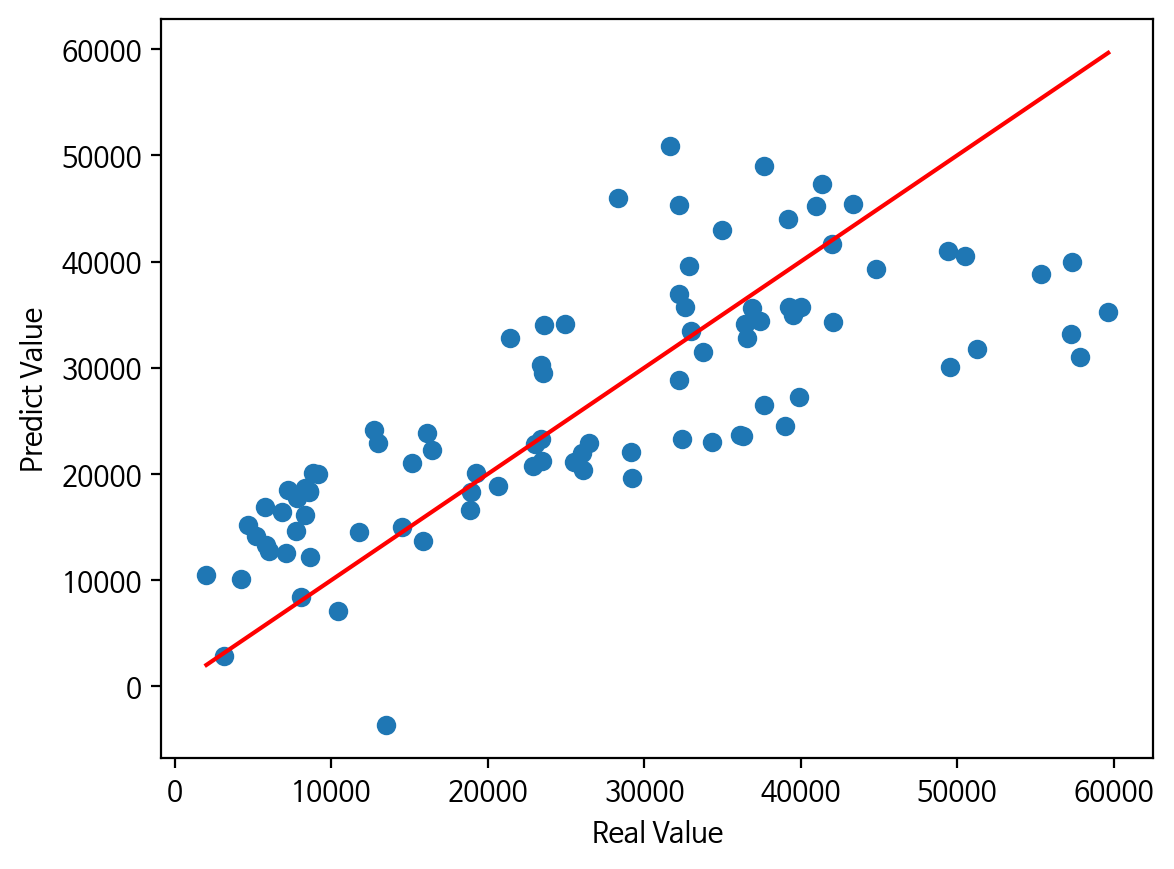

In [40]:
# 평가용 데이터의 최솟값과 최댓값을 x좌표로 설정한다.
x = np.arange(np.min(y_test), np.max(y_test) + 1)

# 평가용 데이터(X_test)의 예측값을 y_pred에 저장한다.
y_pred = model.predict(X_test)

# 평가용 레이블(y_test)은 x축, 평가용 데이터의 예측값(y_pred)은 y축으로 하여 산점도를 그린다.
plt.scatter(y_test,y_pred)

# x, y축 레이블을 설정한다.
plt.xlabel('Real Value')
plt.ylabel('Predict Value')

# y=x 그래프를 기준선으로 선그래프를 그린다.
plt.plot(x, x, 'r')
plt.show( )

예측값이 실젯값을 얼마나 잘 예측했는지 확인하기 위해 실젯값은 x축, 예측값은 y축으로 산점도를 표시했다. 실젯값과 예측값이 y = x 그래프 근처에 있을수록 잘 예측했다고 판단할 수 있다.

####6. 예측하기

학습된 모델을 활용하여 예측해 보자.

① 예측 입력값 저장하기

*   ‌‌학습된 모델을 활용하기 위해 ‘요일’, ‘평균기온’, ‘강수량’을 입력하면
공공 자전거 대여 건수를 예측한 결과를 출력하는 프로그램을 만들어 보자.
*   ‌모델 예측에 입력될 데이터는 2차원 리스트의 형태이며, 요일은 원-핫 인코딩 형태로 입력되어야 하므로 변환과정을 거쳐야 한다.

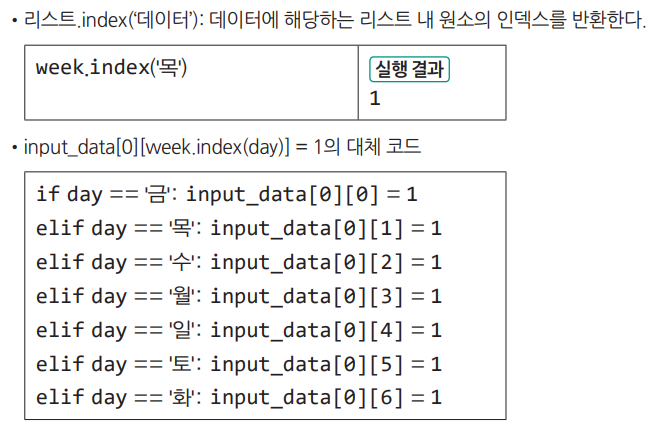

In [45]:
# 새로운 데이터 입력받기
# 속성 금목수월일토화 기온 강수량
# 인덱스 0 1 2 3 4 5 6 7 8

# 입력용 2차원 리스트를 생성하고, 모두 0으로 초기화한다.
input_data = [[0, 0, 0, 0, 0, 0, 0, 0, 0.0]]

# 요일을 한글로 입력받기 위해 ‘금’~‘화’까지 글자를 week 리스트에 저장한다.
week = list('금 목 수 월 일 토 화'.split( ))

# 한 글자의 요일을 입력받아 day 변수에 저장한다.
day = input('요일은(금, 목, 수, 월, 일, 토, 화)?')

# 입력된 day에 해당하는 week 내 인덱스를 반환하여,
# input_data 인덱스의 원소값에 1을 저장한다.
input_data[0][week.index(day)] = 1

# 평균기온을 입력받아 실수로 변환하여 input_data의 8번째 원소에 저장한다.
temp = float(input('평균기온은?'))
input_data[0][7] = temp

# 강수량을 입력받아 실수로 변환하여 input_data의 9번째 원소에 저장한다.
rain = float(input('강수량은?'))
input_data[0][8] = rain

# 입력된 데이터를 출력한다.
print(input_data)

요일은(금, 목, 수, 월, 일, 토, 화)?목
평균기온은?30
강수량은?0
[[0, 1, 0, 0, 0, 0, 0, 30.0, 0.0]]


② 입력값 예측하기

입력된 데이터를 구현된 모델에 입력하여 공공 자전거 대여 건수를 출력해 보자.

In [46]:
# 학습된 모델에 input_data를 입력하여 예측값을 rent 변수에 저장한다.
rent = model.predict(input_data)

# 결괏값을 출력한다.
print('예상 대여 건수: ', int(rent), '대')

예상 대여 건수:  47408 대


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


입력값을 다르게 해서 예측값을 확인해 보자.